In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss
from time import  perf_counter
import psutil
import os

process = psutil.Process(os.getpid())

# Part 1

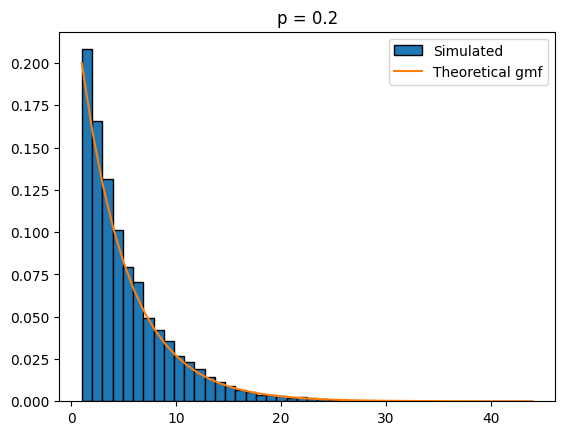

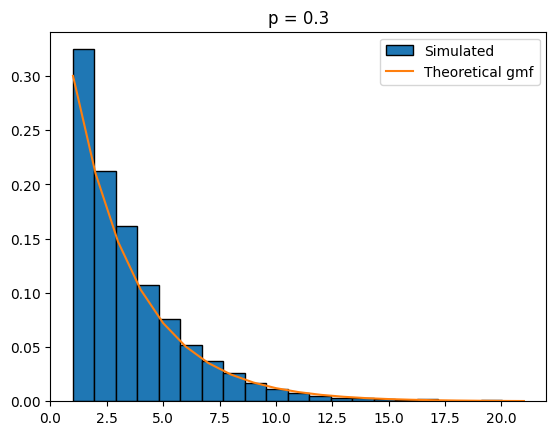

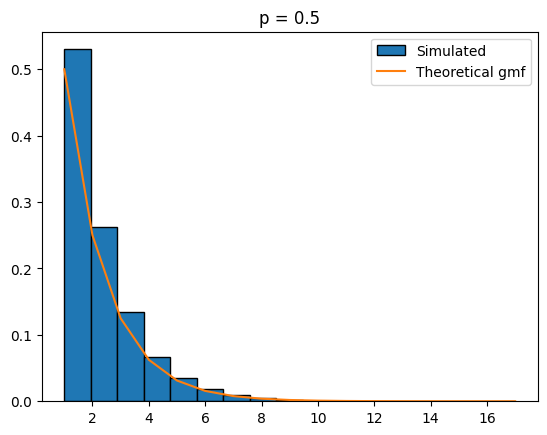

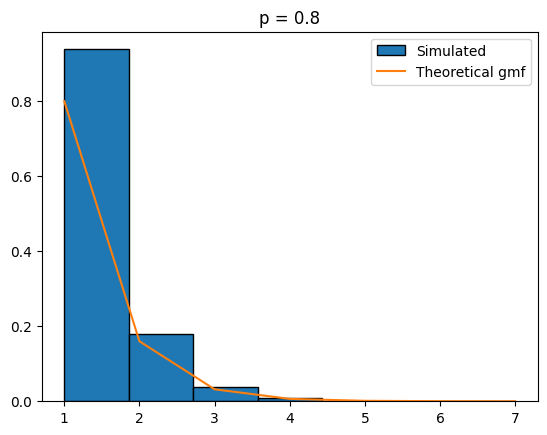

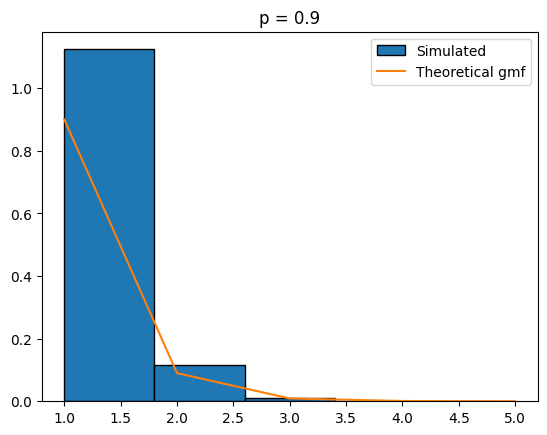

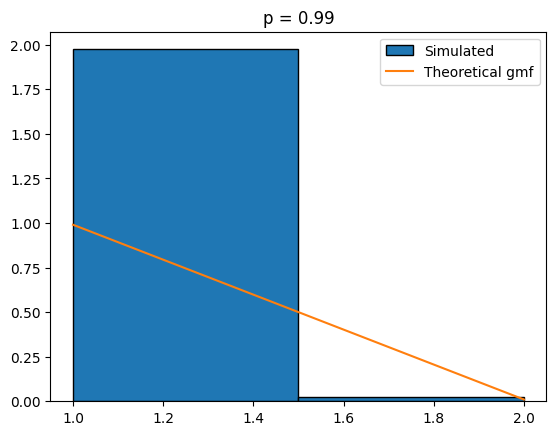

In [2]:
np.random.seed(30)
p = [0.2,0.3,0.5,0.8, 0.9, 0.99]

for i in range(len(p)):
    # Simulate
    U = np.random.uniform(low=0,high=1,size=10_000)
    X = np.floor(np.log(U)/np.log(1-p[i])) + 1
    
    # theoretical
    x = np.arange(1, np.max(X) + 1)
    y = ss.geom.pmf(x, p[i])

    # Plot
    plt.hist(X.astype(np.int8),density=True,bins=int(np.max(X)), edgecolor="black", label="Simulated")
    plt.plot(x,y, label="Theoretical gmf")
    plt.legend()
    plt.title(f"p = {p[i]}")
    plt.show()

# Part 2 and Part 3
## Direct (crude) method

In [3]:
Xi = np.array([1,2,3,4,5,6])
pi = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

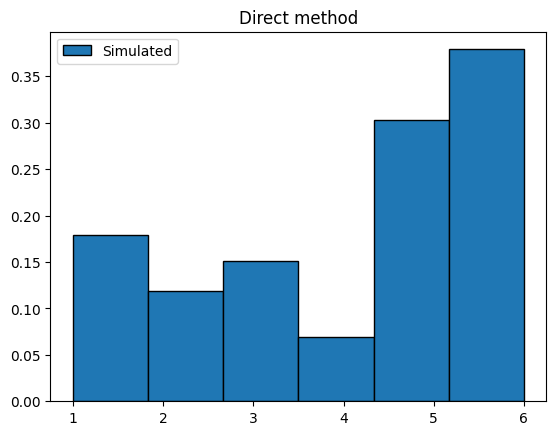

Time to generate: 0.009837875026278198
Memory usage: 4.58752 MB
Accuracy of distribution (max difference between observed and given distribution): 0.06646000000000013


In [31]:
mem1 = process.memory_info().rss
t1 = perf_counter()
# Make sum
Pi = np.cumsum(pi)

# Simulate 
np.random.seed(30)
U = np.random.uniform(low=0,high=1,size=10_000)

# Sort
X_direct = Xi[np.searchsorted(Pi, U)]
t2 = perf_counter()
mem2 = process.memory_info().rss

# Plot
counts,_,_ = plt.hist(X_direct.astype(np.int8),density=True,bins=len(Xi), edgecolor="black", label="Simulated")
plt.legend()
plt.title("Direct method")
plt.show()

print(f"Time to generate: {t2-t1}")
print(f"Memory usage: {(mem2-mem1)*1e-6} MB")
print(f"Accuracy of distribution (max difference between observed and given distribution): {np.max(np.abs(pi-counts))}")

## The rejection method (simple)

In [10]:
Xi = np.array([1,2,3,4,5,6])
pi = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])

In [29]:
mem1 = process.memory_info().rss
t1 = perf_counter()
c = np.max(pi) + 0.1
X_reject = np.empty(10_000, dtype=np.int8)
k = len(Xi)

np.random.seed(30)
for i in range(10_000):

    while True:
        U1,U2 = np.random.uniform(size=2)
        I = int(np.floor(k*U1) + 1)

        if U2 <= pi[I-1]/c:
            X_reject[i] = I
            break
t2 = perf_counter()
mem2 = process.memory_info().rss

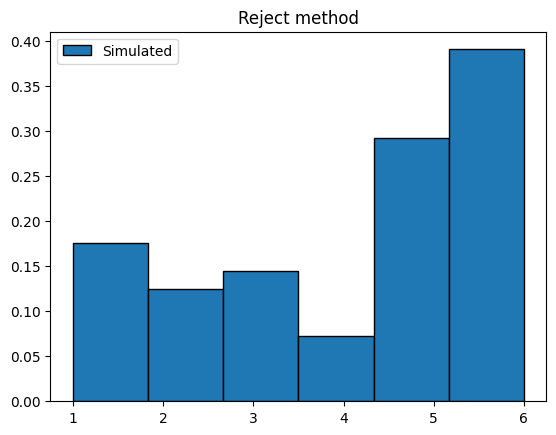

Time to generate: 0.06355333304964006
Memory usage: 0.065536 MB
Accuracy of distribution (max difference between observed and given distribution): 0.07810000000000011


In [30]:
# Plot
counts,_,_ = plt.hist(X_reject.astype(np.int8),density=True,bins=k, edgecolor="black", label="Simulated")
plt.legend()
plt.title("Reject method")
plt.show()

print(f"Time to generate: {t2-t1}")
print(f"Memory usage: {(mem2-mem1)*1e-6} MB")
print(f"Accuracy of distribution (max difference between observed and given distribution): {np.max(np.abs(pi-counts))}")

## The Alias method

In [21]:
Xi = np.array([1,2,3,4,5,6])
pi = np.array([7/48, 5/48, 1/8, 1/16, 1/4, 5/16])
k = len(Xi)

mem1 = process.memory_info().rss
t1 = perf_counter()
# Generate L and F
L = np.arange(k)
F = k*pi
eps = 1e-9

G = list(np.where(F > 1)[0])
S = list(np.where(F < 1)[0])

while len(S) != 0:
    i = G[0]
    j = S[0]

    L[j] = i
    F[i] = F[i] - (1-F[j])

    if F[i] < (1-eps):
        G.pop(0)
        S.append(i)
    
    S.pop(0)
    

X_alias = np.empty(10_000, dtype=np.int8)

np.random.seed(30)
for i in range(10_000):

    U1,U2 = np.random.uniform(size=2)
    I = int(np.floor(k*U1) + 1)

    idx = I-1

    if U2 <= F[idx]:
        X_alias[i] = Xi[idx]
    else:
        X_alias[i] = Xi[L[idx]]

t2 = perf_counter()
mem2 = process.memory_info().rss

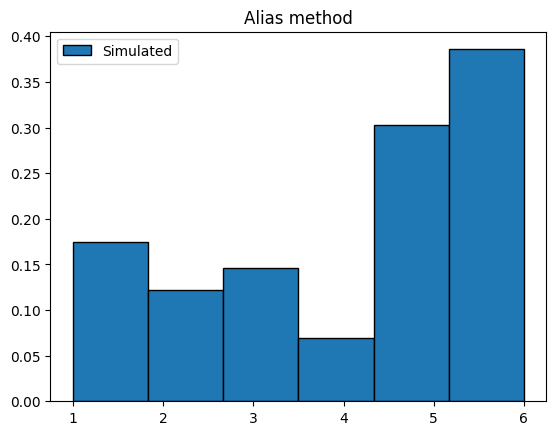

Time to generate: 0.035305915982462466
Memory usage: 0.016384 MB
Accuracy of distribution (max difference between observed and given distribution): 0.07330000000000014


In [22]:
# Plot
counts,_,_ = plt.hist(X_alias.astype(np.int8),density=True,bins=k, edgecolor="black", label="Simulated")
plt.legend()
plt.title("Alias method")
plt.show()

print(f"Time to generate: {t2-t1}")
print(f"Memory usage: {(mem2-mem1)*1e-6} MB")
print(f"Accuracy of distribution (max difference between observed and given distribution): {np.max(np.abs(pi-counts))}")

# Part 4

The esiest to implement is the 